In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import time

In [10]:
X, y = make_classification(
    n_samples=200, 
    n_features=5000, 
    n_informative=50, 
    n_redundant=0, 
    random_state=2137, 
    shuffle=False
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2137)

# A

In [11]:
start_time = time.time()

rf = RandomForestClassifier(n_estimators=100, random_state=2137)
rf.fit(X_train, y_train)
end_time = time.time()

y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)
training_time = end_time - start_time

importances = rf.feature_importances_
non_zero_importances = np.sum(importances > 0)

print(f"Czas treningu: {training_time:.4f} s")
print(f"Accuracy Train: {acc_train:.4f} (powinno być blisko 1.0)")
print(f"Accuracy Test:  {acc_test:.4f} (powinno być znacznie niższe)")
print(f"Liczba cech z niezerowym importance: {non_zero_importances} / 5000 ~ {non_zero_importances / 5000 * 100:.2f}%")

Czas treningu: 0.2633 s
Accuracy Train: 1.0000 (powinno być blisko 1.0)
Accuracy Test:  0.4500 (powinno być znacznie niższe)
Liczba cech z niezerowym importance: 1102 / 5000 ~ 22.04%


# B

In [12]:
from sklearn.feature_selection import SelectKBest, f_classif

k_values = [50, 100, 200]
results = []

for k in k_values:
    selector = SelectKBest(f_classif, k=k)
    selector.fit(X_train, y_train)
    
    X_train_selected = selector.transform(X_train)
    X_test_selected = selector.transform(X_test)
    
    rf = RandomForestClassifier(n_estimators=100, random_state=2137)
    rf.fit(X_train_selected, y_train)
    
    acc = accuracy_score(y_test, rf.predict(X_test_selected))
    results.append({"k": k, "Test Accuracy": acc})
    print(f"Dla k={k}: Test Accuracy = {acc:.4f}")


Dla k=50: Test Accuracy = 0.4000
Dla k=100: Test Accuracy = 0.4000
Dla k=200: Test Accuracy = 0.5000


# C

In [ ]:
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

n_features_to_select = 50

rf_rfe = RandomForestClassifier(n_estimators=50, random_state=2137)
rfe = RFE(estimator=rf_rfe, n_features_to_select=n_features_to_select, step=100)
rfe.fit(X_train, y_train)
selected_rfe = set(np.where(rfe.support_)[0]) # Indeksy wybranych cech

lasso = LogisticRegression(penalty='l1', C=0.5, solver='liblinear', random_state=2137)
lasso_selector = SelectFromModel(lasso, max_features=n_features_to_select) # max_features to bezpiecznik
lasso_selector.fit(X_train, y_train)
selected_lasso = set(np.where(lasso_selector.get_support())[0])

rf_embedded = RandomForestClassifier(n_estimators=100, random_state=2137)
rf_embedded.fit(X_train, y_train)
rf_selector = SelectFromModel(rf_embedded, max_features=n_features_to_select, threshold=-np.inf)
rf_selector.fit(X_train, y_train)
selected_rf = set(np.where(rf_selector.get_support())[0])

print(f"\nLiczba cech wybranych przez RFE: {len(selected_rfe)}")
print(f"Liczba cech wybranych przez Lasso: {len(selected_lasso)}")
print(f"Liczba cech wybranych przez RF Importance: {len(selected_rf)}")

common_all = selected_rfe.intersection(selected_lasso).intersection(selected_rf)
print(f"\nLiczba cech wspólnych dla WSZYSTKICH trzech metod: {len(common_all)}")

true_features = set(range(50)) # Pierwsze 50 cech to te "prawdziwe" w naszym zbiorze
print(f"Ile z 'prawdziwych' cech znalazło RFE? {len(selected_rfe.intersection(true_features))}/50")
print(f"Ile z 'prawdziwych' cech znalazło Lasso? {len(selected_lasso.intersection(true_features))}/50")

/Users/zoga/Studia-II/Uczenie-Maszynowe/Lista11/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/zoga/Studia-II/Uczenie-Maszynowe/Lista11/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



Liczba cech wybranych przez RFE: 50
Liczba cech wybranych przez Lasso: 50
Liczba cech wybranych przez RF Importance: 50

Liczba cech wspólnych dla WSZYSTKICH trzech metod: 1
Ile z 'prawdziwych' cech znalazło RFE? 7/50
Ile z 'prawdziwych' cech znalazło Lasso? 19/50


# D

Wymiar p=20: Test Accuracy = 0.7000
Wymiar p=100: Test Accuracy = 0.6500
Wymiar p=500: Test Accuracy = 0.4667
Wymiar p=1000: Test Accuracy = 0.5000
Wymiar p=5000: Test Accuracy = 0.3667


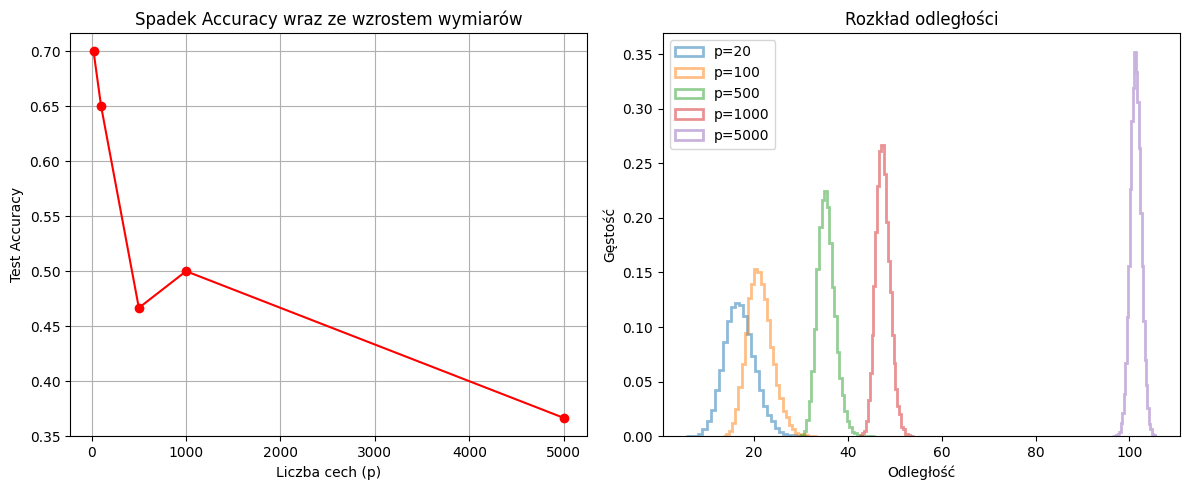

In [6]:
from scipy.spatial.distance import pdist

n_samples = 200
p_values = [20, 100, 500, 1000, 5000] 
accuracies = []
distances_dict = {}

for p in p_values:
    X, y = make_classification(n_samples=n_samples, n_features=p, 
                               n_informative=20, n_redundant=0, 
                               random_state=42, shuffle=False)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2137)
    
    rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    acc = accuracy_score(y_test, rf.predict(X_test))
    accuracies.append(acc)
    print(f"Wymiar p={p}: Test Accuracy = {acc:.4f}")
    
    # pdist zwraca skondensowaną macierz odległości euklidesowej
    dists = pdist(X)
    distances_dict[p] = dists

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(p_values, accuracies, marker='o', color='red')
plt.title("Spadek Accuracy wraz ze wzrostem wymiarów")
plt.xlabel("Liczba cech (p)")
plt.ylabel("Test Accuracy")
plt.grid(True)

plt.subplot(1, 2, 2)
for p in p_values:
    dists = distances_dict[p]
    plt.hist(dists , bins=30, density=True, alpha=0.5, histtype='step', linewidth=2, label=f'p={p}')

plt.title("Rozkład odległości")
plt.xlabel("Odległość")
plt.ylabel("Gęstość")
plt.legend()
plt.tight_layout()
plt.show()